Jupyter environment detected. Enabling Open3D WebVisualizer.
[Open3D INFO] WebRTC GUI backend enabled.
[Open3D INFO] WebRTCWindowSystem: HTTP handshake server disabled.


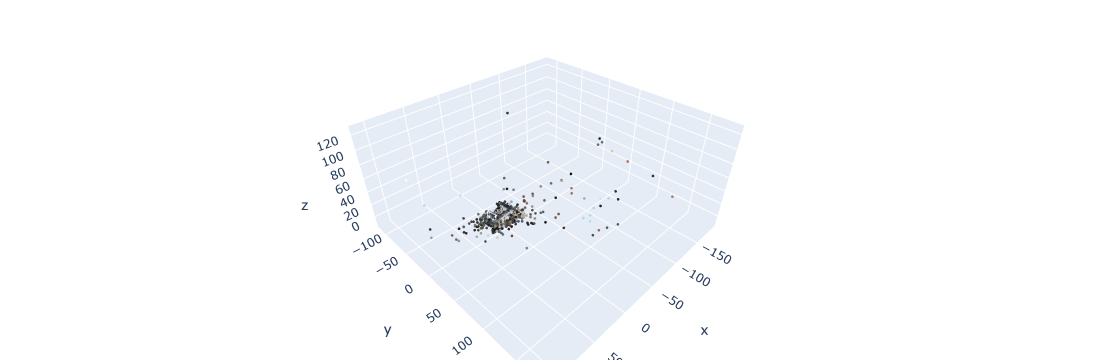

In [1]:
import load_sfm_data
import numpy as np

import pycolmap
import plotly.graph_objects as go

# import os
# # Force headless / surfaceless EGL rendering
# os.environ['EGL_PLATFORM'] = 'surfaceless'
# os.environ['LIBGL_ALWAYS_SOFTWARE'] = 'true'

import open3d as o3d

def get_data():
    folder = "/mnt/e/dataset/sfm/courtyard_dslr_undistorted/courtyard/dslr_calibration_undistorted"
    parser = load_sfm_data.SfMParser(folder)
    parser.parse_cameras("cameras.txt")
    parser.parse_images("images.txt")
    parser.parse_points3d("points3D.txt")
    return(parser.cameras, parser.images, parser.points3d)

def plot_pcd(points, colors):
    # Leverage your already extracted numpy arrays directly in the browser
    fig = go.Figure(data=[
        go.Scatter3d(
            x=points[:, 0],
            y=points[:, 1],
            z=points[:, 2],
            mode='markers',
            marker=dict(
                size=1.5,
                color=colors, # Uses your normalized 0-1 RGB array
            )
        )
    ])

    fig.update_layout(
        scene=dict(aspectmode='data'),
        margin=dict(l=0, r=0, b=0, t=0)
    )
    fig.show()

cameras, images, points_3d = get_data()
# print(cameras)

points = []
colors = []
for p3d_id, p3d in points_3d.items():
    points.append([p3d.x, p3d.y, p3d.z])
    colors.append([p3d.r, p3d.g, p3d.b])
points = np.array(points)
colors = np.array(colors) / 255.0
plot_pcd(points, colors)

In [2]:
reconstruction = pycolmap.Reconstruction()

for c_id, camera in cameras.items():
    cam = pycolmap.Camera()
    cam.camera_id = c_id
    cam.model = pycolmap.CameraModelId.PINHOLE
    cam.width = camera.width
    cam.height = camera.height
    cam.params = camera.params
    
    reconstruction.add_camera_with_trivial_rig(cam)

In [3]:
for p3d_id, p3d in points_3d.items():
    # print(p3d)
    # break
    p = pycolmap.Point3D()
    noise = np.random.normal(loc=0.0, scale=0.02, size=3)
    p.xyz = np.array([p3d.x, p3d.y, p3d.z]) + noise
    p.color = np.array([p3d.r, p3d.g, p3d.b])
    # p.track = pycolmap.Track()
    reconstruction.add_point3D_with_id(p3d.point3d_id, p)

In [4]:
# valid_point3D_ids = set(reconstruction.point3D_ids())
for im_id, image in images.items():
    img = pycolmap.Image()
    img.image_id = im_id
    img.camera_id = image.camera_id
    img.name = image.name
    
    q = np.array([image.qw,image.qx, image.qy, image.qz])
    t = np.array([image.tx, image.ty, image.tz])
    cam_from_world_pose = pycolmap.Rigid3d(q, t)

    # p2d = []
    # for p in image.points2d:
    #     xy = [p.x, p.y]
    #     p_id = p.point3d_id
    #     # if p_id in valid_point3D_ids:
    #     if p_id > -1 and reconstruction.exists_point3D(p_id):
    #         p2d.append(pycolmap.Point2D(xy=xy, point3D_id=p_id))
    p2d = []
    valid_3d_ids = []
    
    for p in image.points2d:
        xy = [p.x, p.y]
        p_id = p.point3d_id
        
        if p_id > -1 and reconstruction.exists_point3D(p_id):
            # INITIALIZE EMPTY: This allows add_observation to work without an assertion error
            p2d.append(pycolmap.Point2D(xy=xy, point3D_id=pycolmap.INVALID_POINT3D_ID))
            valid_3d_ids.append(p_id)
        else:
            p2d.append(pycolmap.Point2D(xy=xy, point3D_id=pycolmap.INVALID_POINT3D_ID))
            valid_3d_ids.append(None)
    img.points2D = pycolmap.Point2DList(p2d)

    # print(img)
    reconstruction.add_image_with_trivial_frame(img, cam_from_world_pose)
    for idx, target_3d_id in enumerate(valid_3d_ids):
        if target_3d_id is not None:
            # This safely updates the image point2D AND the 3D point visibility graph concurrently
            reconstruction.add_observation(
                target_3d_id, 
                pycolmap.TrackElement(image_id=im_id, point2D_idx=idx)
            )
    # for idx, p in enumerate(p2d):
    #     reconstruction.add_observation(p.point3D_id, pycolmap.TrackElement(image_id=im_id, point2D_idx=idx))

In [5]:
options = pycolmap.BundleAdjustmentOptions()
options.refine_rig_from_world = False
options.refine_focal_length = False

pycolmap.bundle_adjustment(reconstruction, options)

I20260715 19:04:18.871122 133351436411200 bundle_adjustment.cc:70] === Global bundle adjustment ===
I20260715 19:04:19.964245 133351436411200 bundle_adjustment_ceres.cc:1146] Bundle adjustment report
    Residuals : 204868
   Parameters : 73203
   Iterations : 101
         Time : 1.00239 [s]
 Initial cost : 235714 [px]
   Final cost : 2680.22 [px]
  Termination : NO_CONVERGENCE

I20260715 19:04:19.968833 133351436411200 timer.cc:90] Elapsed time: 0.018 [minutes]


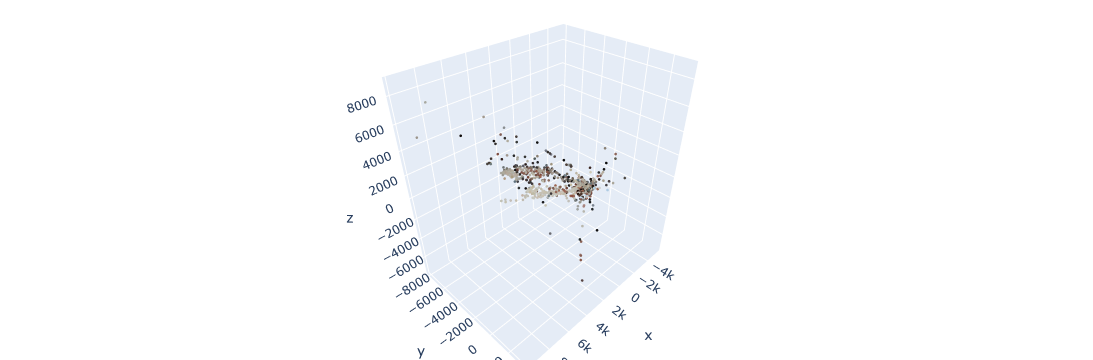

In [6]:
points = []
colors = []

for pt_id, point in reconstruction.points3D.items():
    points.append(point.xyz)
    colors.append(point.color / 255.0) # Convert 0-255 RGB to 0-1 for plotting

points = np.array(points)
colors = np.array(colors)


# Leverage your already extracted numpy arrays directly in the browser
fig = go.Figure(data=[
    go.Scatter3d(
        x=points[:, 0],
        y=points[:, 1],
        z=points[:, 2],
        mode='markers',
        marker=dict(
            size=1.5,
            color=colors, # Uses your normalized 0-1 RGB array
        )
    )
])

fig.update_layout(
    scene=dict(aspectmode='data'),
    margin=dict(l=0, r=0, b=0, t=0)
)
fig.show()


In [2]:
camera_params = np.array([cameras[i].params for i in range(len(cameras))])
print(camera_params)

[[3411.42 3410.02 3116.72 2062.52]
 [3409.58 3409.44 3115.16 2064.73]
 [3407.41 3408.08 3112.83 2065.6 ]
 [3408.35 3408.8  3114.7  2070.92]]


In [3]:
points_3d_xyz = np.array([(p.x, p.y, p.z) for _, p in points_3d.items()])
points_3d_id = [p.point3d_id for _, p in points_3d.items()]
print(points_3d_xyz[0, :], len(points_3d_id))

[-2.09605 -2.94315 18.2294 ] 33487


In [4]:
obs_2d = []
obs_to_3d = []
pose_params = []
obs_to_cam = []
obs_to_pose = []
for idx, (_, image) in enumerate(images.items()):
    if image.camera_id == 1:
        # print(image)
        # R = quat_to_matrix([image.qw,image.qx, image.qy, image.qz])
        # rvec = quat_to_rvec([image.qw,image.qx, image.qy, image.qz])
        # t = jnp.array([image.tx, image.ty, image.tz])
        # pose_params.append([*rvec, *t])
        pose_params.append([image.qw,image.qx, image.qy, image.qz, image.tx, image.ty, image.tz])
        
        p2d = np.array([(p.x, p.y, p.point3d_id) for p in image.points2d if p.point3d_id > -1])
        p2d_uv = p2d[:, :2]
        p2d_id = p2d[:, -1].astype('int')
        p2d_id = [points_3d_id.index(i) for i in p2d_id]
        n_obs = len(p2d_id)
        
        obs_2d.extend(p2d_uv)
        obs_to_3d.extend(p2d_id)
        # obs_to_cam.append(image.camera_id)
        # obs_to_pose.append(idx)
        obs_to_cam.extend([image.camera_id for _ in range(n_obs)])
        obs_to_pose.extend([idx for _ in range(n_obs)])

obs_2d = np.array(obs_2d)
obs_to_3d = np.array(obs_to_3d)
obs_to_cam = np.array(obs_to_cam)
obs_to_pose = np.array(obs_to_pose)
pose_params = np.array(pose_params)
print(obs_to_3d.shape)

# mask = np.isin(np.array(points_3d_id), obs_to_3d)
# points_3d_xyz = points_3d_xyz[mask, :]
# points_3d_id = np.array(points_3d_id)[mask]

# print(points_3d_xyz[0, :], len(points_3d_id))

(87869,)


In [5]:
class Point3Var(jaxls.Var[jax.Array], default_factory=lambda: jnp.zeros(3)):
    """3D landmark position."""

class IntrVar(jaxls.Var[jax.Array], default_factory=lambda: jnp.zeros(4)):
    """Cam Intrinsics."""

n_poses = pose_params.shape[0]
n_cams = camera_params.shape[0]
n_points = len(points_3d_id)

@jax.jit
def project_point_single(
    point_world: jax.Array,
    T_camera_world: jaxlie.SE3,
    cam_intr: jax.Array,
) -> jax.Array:
    """Project 3D point to 2D using pinhole camera model.

    Args:
        point_world: 3D point in world frame (3,)
        T_camera_world: Camera pose (world to camera transform)
        focal: Focal length

    Returns:
        2D projected point (2,)
    """
    # Transform point to camera frame.
    point_cam = T_camera_world @ point_world

    # Perspective projection (BAL convention: -P_xy / P_z)
    p = -point_cam[:2] / point_cam[2]

    # Unpack the 4 focal and principal point parameters
    fx, fy, cx, cy = cam_intr[0], cam_intr[1], cam_intr[2], cam_intr[3]
    
    # Apply calibration matrix mapping to pixel space
    u = fx * p[0] + cx
    v = fy * p[1] + cy
    return jnp.array([u, v])

# Automatically vectorize across your N observations
project_point = jax.vmap(project_point_single, in_axes=(0, 0, 0))

In [6]:
print(obs_2d.shape, obs_to_3d.shape, obs_to_pose.shape)

(87869, 2) (87869,) (87869,)


In [7]:
# 1. DEFINE YOUR COST FACTORY TO PROCESS A SINGLE OBSERVATION AT A TIME
@jaxls.Cost.factory
def single_reprojection_cost(
    vals: jaxls.VarValues,
    pose_var: jaxls.SE3Var,
    point_var: Point3Var,
    
    # These inputs are mapped per-observation because they are broadcasted by jaxls
    cam_intr: jax.Array,   # Shape: (4,)
    observed_px: jax.Array, # Shape: (2,)
) -> jax.Array:
    
    # jaxls automatically extracts the specific single observation elements
    pose = vals[pose_var]    # Single jaxlie.SE3 object
    point = vals[point_var]  # Single 3D point array (3,)

    # Run the single projection
    projected = project_point_single(point, pose, cam_intr)
    residual = projected - observed_px

    # Robust Huber Loss weighting
    delta = 2.0  
    abs_r = jnp.abs(residual) + 1e-8
    weight = jax.lax.stop_gradient(jnp.where(abs_r > delta, delta / abs_r, 1.0))
    
    return residual * jnp.sqrt(weight)


unified_cost = single_reprojection_cost(
    jaxls.SE3Var(id=obs_to_pose),      # Slices correct poses automatically
    Point3Var(id=obs_to_3d),         # Slices correct 3D points automatically
    cam_intr=camera_params[1, :][None, :],         # Slices correct intrinsics matching the observation
    observed_px=obs_2d,                # Slices correct pixels matching the observation
)


unique_pose_vars = jaxls.SE3Var(id=obs_to_pose)
unique_p3d_vars  = Point3Var(id=obs_to_3d)

In [ ]:
problem = jaxls.LeastSquaresProblem(
    costs=[unified_cost], 
    variables=[unique_pose_vars, unique_p3d_vars]
)

problem = problem.analyze()

2026-07-15 06:46:47.960 | INFO     | jaxls._problem:analyze:237 - Building optimization problem with 87869 terms and 175738 variables: 87869 costs, 0 eq_zero, 0 leq_zero, 0 geq_zero
2026-07-15 06:46:48.300 | INFO     | jaxls._problem:analyze:364 - Vectorizing group with 87869 costs, 2 variables each: single_reprojection_cost


In [25]:
initial_vals = jaxls.VarValues.make([
    unique_pose_vars.with_value(pose_params),
    unique_p3d_vars.with_value(points_3d_xyz)
])

solution = problem.solve(initial_vals, linear_solver="conjugate_gradient", sparse_mode=True)

TypeError: dot_general requires contracting dimensions to have the same shape, got (7,) and (33487,).

In [11]:
@jax.jit
def project_point_single(
    point_world: jax.Array,
    T_camera_world: jaxlie.SE3,
    cam_intr: jax.Array,
) -> jax.Array:
    """Project 3D point to 2D using pinhole camera model.

    Args:
        point_world: 3D point in world frame (3,)
        T_camera_world: Camera pose (world to camera transform)
        focal: Focal length

    Returns:
        2D projected point (2,)
    """
    # Transform point to camera frame.
    point_cam = T_camera_world @ point_world

    # Perspective projection (BAL convention: -P_xy / P_z)
    p = -point_cam[:2] / point_cam[2]

    # Unpack the 4 focal and principal point parameters
    fx, fy, cx, cy = cam_intr[0], cam_intr[1], cam_intr[2], cam_intr[3]
    
    # Apply calibration matrix mapping to pixel space
    u = fx * p[0] + cx
    v = fy * p[1] + cy
    return jnp.array([u, v])

# Automatically vectorize across your N observations
project_point = jax.vmap(project_point_single, in_axes=(0, 0, 0))

@jaxls.Cost.factory
def reprojection_cost(
    vals: jaxls.VarValues,
    cam_var: IntrVar,
    pose_var: jaxls.SE3Var,
    point_var: Point3Var,

    # pose_idxs: jax.Array,
    # cam_idxs: jax.Array,
    # point_3d_idxs: jax.Array,
    observed_px: jax.Array,
) -> jax.Array:
    """Reprojection error with Huber loss for robustness."""
    # pose = vals[pose_var]
    # point = vals[point_var]
    # # point = point[point_3d_idxs]
    # cam_intr = vals[cam_var]

    # # Retrieve all parameters as unified vectorized matrices
    # all_poses = vals[pose_var]       # Shape: (N_poses, ...)
    # all_points = vals[point_var]     # Shape: (35000, 3)
    # all_cams = vals[cam_var]         # Shape: (N_cameras, 4)
    
    # # Scatter gather across all observations inside JAX memory space
    # poses_per_obs = all_poses[pose_idxs]
    # points_per_obs = all_points[point_idxs]
    # cams_per_obs = all_cams[cam_idxs]

    poses_per_obs = vals[pose_var]       
    points_per_obs = vals[point_var]
    cams_per_obs = vals[cam_var]   
    
    # projected = project_point(point, pose, cam_intr)
    # projected = project_point(points_per_obs, poses_per_obs, cams_per_obs)
    projected = project_point_single(points_per_obs, poses_per_obs, cams_per_obs)
    residual = projected - observed_px

    # IRLS-style Huber weighting for robustness to outliers.
    # For |r| <= delta: weight = 1 (quadratic region)
    # For |r| > delta: weight = delta / |r| (linear region)
    # stop_gradient prevents instabilities from differentiating through weights.
    delta = 2.0  # pixels
    abs_r = jnp.abs(residual) + 1e-8
    weight = jax.lax.stop_gradient(jnp.where(abs_r > delta, delta / abs_r, 1.0))
    # return residual * jnp.sqrt(weight)

# pose_vars = [jaxls.SE3Var(id=i) for i in range(pose_params.shape[0])]
# cam_intr_vars = [IntrVar(id=i) for i in range(camera_params.shape[0])]
# p3d_vars = [Point3Var(id=i) for i in range(points_3d_xyz.shape[0])]
# pose_vars = jaxls.SE3Var(id=jnp.arange(pose_params.shape[0]))
# cam_intr_vars = IntrVar(id=jnp.arange(camera_params.shape[0]))
# p3d_vars = Point3Var(id=jnp.arange(n_points))
pose_vars = jaxls.SE3Var(id=obs_to_pose)
cam_intr_vars = IntrVar(id=obs_to_cam)
p3d_vars = Point3Var(id=obs_to_3d)

costs = [reprojection_cost(
    cam_intr_vars,
    pose_vars,
    p3d_vars,
    # pose_idxs=obs_to_pose,
    # cam_idxs=obs_to_cam,
    # point_idxs=obs_to_3d,
    observed_px=obs_2d,
)]

problem = jaxls.LeastSquaresProblem(costs, [cam_intr_vars, pose_vars, p3d_vars])

In [10]:
problem = problem.analyze()

2026-07-15 04:16:06.322 | INFO     | jaxls._problem:analyze:237 - Building optimization problem with 138821 terms and 416463 variables: 138821 costs, 0 eq_zero, 0 leq_zero, 0 geq_zero


ValueError: vmap got inconsistent sizes for array axes to be mapped:
  * one axis had size 3: axis 0 of argument point_world of type float32[3];
  * one axis had size 7: axis 0 of argument T_camera_world[<flat index 0>] of type float32[7];
  * one axis had size 4: axis 0 of argument cam_intr of type float32[4]

In [8]:
print(obs_to_pose.shape)

(138821,)
